# Cuaderno de clase
## Mecánica Celeste (2026-1) con Jorge I. Zuluaga
## Virial y tiempo de relajación

En este notebook pondremos en práctica algunos conceptos relacionados con el teorema del virial en el problema gravitacional de los N cuerpos.

## Importar paquetes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rebound as rb
import plotly.graph_objects as go

Estamos trabajando en unidades canónicas:

In [2]:
G = 1

## Generación de un sistema aleatorio de N cuerpos

Vamos a generar las condiciones iniciales de un sistema de N-cuerpos:

In [19]:
# Número de partículas
N = 20

# Semilla de número aleatorios: cambiar para obtener diferentes condiciones iniciales
np.random.seed(3)

# Masas aleatorias uniformes en [0.5, 2], normalizadas a M_total = 1
masas = np.random.uniform(0.5, 2.0, N)
masas /= masas.sum()

# Posiciones uniformes en una esfera de radio R = 1
rcoords   = np.random.uniform(0, 1, N) ** (1/3)          # radio (vol. uniforme)
thetas   = np.arccos(1 - 2 * np.random.uniform(0, 1, N)) # ángulo polar
phis     = 2 * np.pi * np.random.uniform(0, 1, N)        # ángulo azimutal

# Ponemos todas las pocisiones un una matriz de forma (N, 3)
rinis = np.column_stack([
    rcoords * np.sin(thetas) * np.cos(phis),
    rcoords * np.sin(thetas) * np.sin(phis),
    rcoords * np.cos(thetas)
])

# Velocidades iniciales
vinis = np.random.normal(0, 0.5, (N, 3)) # Componentes de velocidad normales con media 0 y desviación estándar 0.5

# Calculamos la velocidad del centro de masa
VCM = np.average(vinis, axis=0, weights=masas)

# Eliminamos el movimiento del centro de masa
vinis -= VCM

Simulemos el sistema con REBOUND:

In [20]:
def simula_ncuerpos_rebound(masas, rinis, vinis, T, Nt):
    n = len(masas)
    sim = rb.Simulation()
    for i in range(n):
        sim.add(m=masas[i],
                x=rinis[i, 0], y=rinis[i, 1], z=rinis[i, 2],
                vx=vinis[i, 0], vy=vinis[i, 1], vz=vinis[i, 2])
    sim.move_to_com()

    # Tiempo todal de integración
    ts = np.linspace(0, T, Nt)

    # Cubo para el almacenamiento de las posiciones
    rps = np.zeros((n, Nt, 3))
    vps = np.zeros((n, Nt, 3))

    for k, t in enumerate(ts):
        sim.integrate(t)
        for j in range(n):
            rps[j, k] = sim.particles[j].xyz
            vps[j, k] = sim.particles[j].vxyz

    return rps, vps

Usa la rutina para simular el sistema:

In [21]:
T = 5
Nt = 1000
rps, vps = simula_ncuerpos_rebound(masas, rinis, vinis, T=T, Nt=Nt)

Ahora animemos las trayectorias:

In [22]:
def anima_ncuerpos(masas, rps, T):
    N = rps.shape[0]
    Nt = rps.shape[1]
    T_total = Nt * (T / Nt)  # tiempo total de la simulación
    
    # Colores de las partículas
    colors_hex = [f'hsl({int(j/N*360)},70%,50%)' for j in range(N)]

    # Submuestreo para que la animación sea fluida pero no pesada
    n_frames = 120
    idx = np.linspace(0, Nt - 1, n_frames, dtype=int)
    s_markers = [min(30, max(4, int(masas[j] * 120 + 4))) for j in range(N)]

    base_traces = []
    for j in range(N):
        base_traces.append(go.Scatter3d(
            x=rps[j, :, 0], y=rps[j, :, 1], z=rps[j, :, 2],
            mode='lines',
            line=dict(color=colors_hex[j], width=1),
            opacity=0.25,
            showlegend=False,
            hoverinfo='skip'
        ))

    # Posiciones iniciales de los cuerpos (frame 0)
    for j in range(N):
        base_traces.append(go.Scatter3d(
            x=[rps[j, idx[0], 0]],
            y=[rps[j, idx[0], 1]],
            z=[rps[j, idx[0], 2]],
            mode='markers',
            marker=dict(color=colors_hex[j], size=s_markers[j],
                        line=dict(color='black', width=0.5)),
            name=f'Cuerpo {j+1}',
            showlegend=False
        ))

    frames = []
    for fi, ki in enumerate(idx):
        frame_data = []
        # Las N primeras trazas son trayectorias (no cambian); actualizamos sólo las N de puntos
        for j in range(N):
            frame_data.append(go.Scatter3d(
                x=[rps[j, ki, 0]],
                y=[rps[j, ki, 1]],
                z=[rps[j, ki, 2]],
            ))
        frames.append(go.Frame(
            data=frame_data,
            traces=list(range(N, 2 * N)),   # índices de las trazas de puntos
            name=str(fi)
        ))

    fig_anim = go.Figure(data=base_traces, frames=frames)
    fig_anim.update_layout(
        title=dict(
            text=f'Animación 3D — {N} cuerpos — T = {T_total} u.t.c.',
            x=0.5
        ),
        scene=dict(
            xaxis_title='x [u.c.]',
            yaxis_title='y [u.c.]',
            zaxis_title='z [u.c.]',
            aspectmode='data'
        ),
        width=860, height=760,
        margin=dict(l=0, r=0, b=0, t=50),
        updatemenus=[dict(
            type='buttons',
            showactive=False,
            y=0.02, x=0.5, xanchor='center',
            buttons=[
                dict(label='▶ Play',
                    method='animate',
                    args=[None, dict(frame=dict(duration=40, redraw=True),
                                    fromcurrent=True, mode='immediate')]),
                dict(label='⏸ Pausa',
                    method='animate',
                    args=[[None], dict(frame=dict(duration=0, redraw=False),
                                        mode='immediate')])
            ]
        )],
        sliders=[dict(
            currentvalue=dict(prefix='Frame: ', visible=True, xanchor='center'),
            pad=dict(t=40),
            steps=[dict(method='animate',
                        args=[[str(fi)], dict(mode='immediate',
                                            frame=dict(duration=0, redraw=True))],
                        label=str(fi))
                for fi in range(n_frames)]
        )]
    )
    fig_anim.show()

Anima el sistema:

In [23]:
anima_ncuerpos(masas, rps, T)

## Cálculo de la energía potencial y cinética total

Calculemos ahora la energía del sistema:

In [24]:
# Diseñamos una rutina porque es un cálculo que se va a repetir varias veces
def calcula_energia(masas, rps, vps):
    U = 0.0
    for i in range(N):
        for j in range(i + 1, N):
            rij = np.linalg.norm(rps[i] - rps[j])
            U  += -G * masas[i] * masas[j] / rij
    K = 0.5 * np.sum(masas[:, None] * vps**2)
    E = K + U
    return K, U, E

Ktotal, Utotal, E = calcula_energia(masas, rinis, vinis)

print(f'Energía cinética inicial: K = {Ktotal:.3f}')
print(f'Energía potencial inicial: U = {Utotal:.3f}')
print(f'Energía total inicial: E = {E:.3f}')

Energía cinética inicial: K = 0.337
Energía potencial inicial: U = -0.565
Energía total inicial: E = -0.229


Como vemos la energía es positiva y por lo tanto el sistema es desligado. Podemos hacer que el sistema sea ligado si ajustamos las velocidades para que la energía cinética sea menor que la potencial:

In [26]:
Kesp = -Utotal/4
vini_ajusts = vinis * np.sqrt(Kesp / Ktotal)

Vuelve a simular y animar y observa:

In [27]:
rps, vps = simula_ncuerpos_rebound(masas, rinis, vini_ajusts, T=T, Nt=Nt)
anima_ncuerpos(masas, rps, T)

Haz un código que muestre cómo evoluciona la energía cinética, la energía potencia y el virial escalar $\dot{G} = 2K + U$ como función del tiempo:

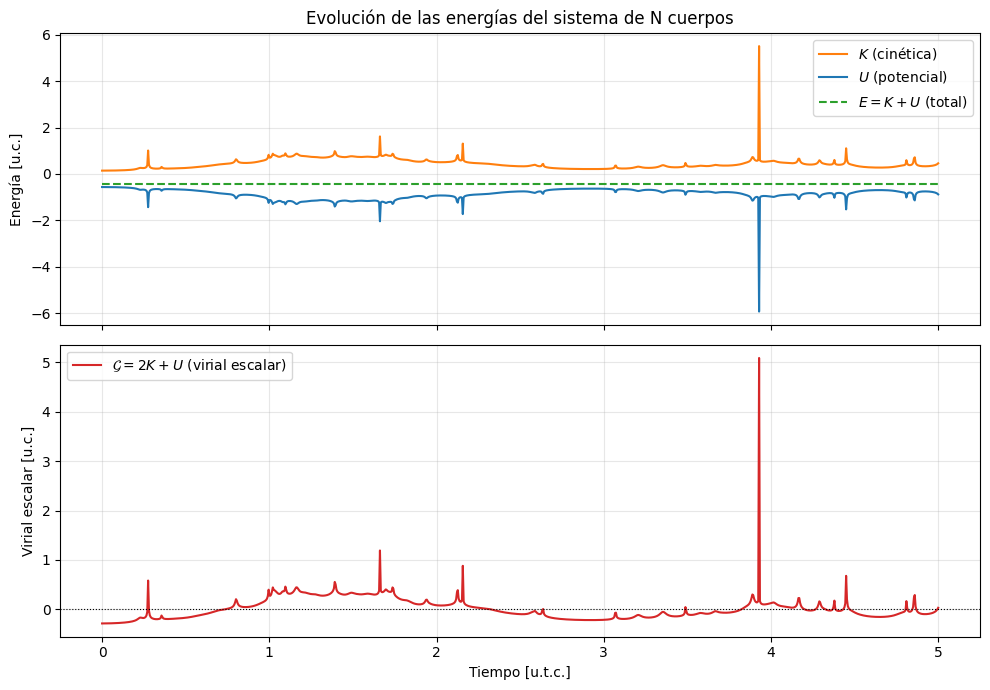

Virial escalar promedio ⟨G⟩ = 0.0151  (≈ 0 indica equilibrio virial)
Energía total inicial:  E₀ = -0.4241
Energía total final:    Ef = -0.4241
Variación relativa: ΔE/E₀ = 2.13e-12


In [29]:
ts = np.linspace(0, T, Nt)

Ks = np.zeros(Nt)
Us = np.zeros(Nt)

for k in range(Nt):
    # Energía cinética en el instante k
    Ks[k] = 0.5 * np.sum(masas[:, None] * vps[:, k, :] ** 2)
    # Energía potencial en el instante k
    for i in range(N):
        for j in range(i + 1, N):
            rij = np.linalg.norm(rps[i, k] - rps[j, k])
            Us[k] += -G * masas[i] * masas[j] / rij

Es = Ks + Us          # Energía total
virial = 2 * Ks + Us  # Virial escalar

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1 = axes[0]
ax1.plot(ts, Ks, label='$K$ (cinética)', color='tab:orange')
ax1.plot(ts, Us, label='$U$ (potencial)', color='tab:blue')
ax1.plot(ts, Es, label='$E = K + U$ (total)', color='tab:green', linestyle='--')
ax1.set_ylabel('Energía [u.c.]')
ax1.legend()
ax1.set_title('Evolución de las energías del sistema de N cuerpos')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(ts, virial, label=r'$\mathcal{G} = 2K + U$ (virial escalar)', color='tab:red')
ax2.axhline(0, color='k', linestyle=':', linewidth=0.8)
ax2.set_xlabel('Tiempo [u.t.c.]')
ax2.set_ylabel('Virial escalar [u.c.]')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Virial escalar promedio ⟨G⟩ = {virial.mean():.4f}  (≈ 0 indica equilibrio virial)')
print(f'Energía total inicial:  E₀ = {Es[0]:.4f}')
print(f'Energía total final:    Ef = {Es[-1]:.4f}')
print(f'Variación relativa: ΔE/E₀ = {abs((Es[-1] - Es[0]) / Es[0]):.2e}')

## Tiempo de cruce y tiempo de relajación

Calcula el tiempo de cruce y el tiempo de relajación del sistema. Compara los valores observados con el comportamiento del virial escalar y comenta.

Aumenta el número de partículas y observa los cambios.

## Un sistema no colisional

Hay sistemas de N-cuerpos en los que el potencial gravitacional varía muy poco espacialmente. A estos sistemas se los conoce como sistemas no colisionales. Abajo generamos las condiciones iniciales de un sistema gravitacional no colisional:

In [ ]:
np.random.seed(1)

N = 20 
M = 1.0   # masa central
m = 0.001  # masa de cada partícula ligera (m << M)

# Parámetros
N_ligeras = N - 1  # número de partículas ligeras
sigma_v_frac = 0.005 # dispersión fraccional de velocidad

# Masas (central + ligeras)
masas = np.concatenate(([M], np.full(N_ligeras, m)))

# Posiciones iniciales en un disco fino (z=0) con densidad superficial ~ uniforme
Rmin, Rmax = 1, 5
rcoords = np.sqrt(np.random.uniform(Rmin**2, Rmax**2, N_ligeras))
phis = np.random.uniform(0, 2*np.pi, N_ligeras)

rinis = np.vstack([
    np.array([[0.0, 0.0, 0.0]]),
    np.column_stack([
        rcoords * np.cos(phis), 
        rcoords * np.sin(phis), 
        np.zeros(N_ligeras)
    ])
])

# Velocidades tangenciales circulares respecto a la masa central
v_circ = np.sqrt(G * M / rcoords)
vx = -v_circ * np.sin(phis)
vy =  v_circ * np.cos(phis)
vz = np.zeros(N_ligeras)

# Velocidades iniciales
vinis = np.vstack([
    np.array([[0.0, 0.0, 0.0]]),
    np.column_stack([vx, vy, vz])
])

# Quitar deriva del centro de masa
VCM = np.average(vinis, axis=0, weights=masas)
vinis -= VCM

Simulemos y animemos:

Haz un gráfico de las energías y del virial escalar: